## **Libraries**

In [ ]:
import tensorflow as tf
from tensorflow.keras import Model,layers
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil             #moving and copying the files
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model


In [ ]:
import kagglehub
path=kagglehub.dataset_download("jessicali9530/celeba-dataset")
print("Dataset download to:",path)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Dataset download to: /kaggle/input/celeba-dataset


In [ ]:
#create a smaller dataset(5000img)
source_folder =os.path.join(path,"img_align_celeba","img_align_celeba")
destination_folder ="celeba_small/faces"
os.makedirs(destination_folder,exist_ok=True)
images= sorted(os.listdir(source_folder))[:5000]
for img in images:
  shutil.copy(
        os.path.join(source_folder,img),
        destination_folder
    )
print("copied",len(img),"images")

copied 10 images


In [ ]:
#Datapreprocessing
IMAGE_SIZE =(64,64)
BATCH_SIZE=32

In [ ]:
from re import I
datagen =ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
#load dataset
train_generator =datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE, #64*64
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)


Found 4000 images belonging to 1 classes.


In [ ]:
validation_generator =datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="validation"
)

Found 1000 images belonging to 1 classes.


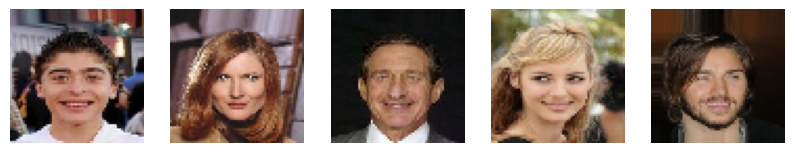

In [ ]:
#Display sample images
images,_= next(train_generator)
plt.figure(figsize=(10,5))
for i in range(5):
  ax=plt.subplot(1,5,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [ ]:
# Build Convolutional Autoencoder
# Encoder is compress
input_img = Input(shape = (64,64,3)) # image size 3 rgb scale

x = Conv2D(   # 32 is filters (3,3) that check window size
    32,       # 64 to 32
    (3,3),
    activation = "relu",
    padding = "same"  # image size
)(input_img)

x = MaxPooling2D((2,2), padding = "same")(x)  # Maxpooling it maximum numbers in matrix (2,2) window size it check

x = Conv2D(
    64,      # here it 32, 32, 64 (64 is we increasing) it compress 32 to 16
    (3,3),     # compressing filters
    activation = "relu",
    padding = "same"
)(x)

encoded = MaxPooling2D(
    (2,2),     # here 16 to 8
    padding = "same"
)(x)

In [ ]:
#decoder
x=Conv2D(
    64,(3,3),
    activation="relu",
    padding="same"

)(encoded)
x=UpSampling2D((2,2))(x)
x=Conv2D(
    32,(3,3),
    activation="relu",
    padding="same"

)(x)
x=UpSampling2D((2,2))(x)
decoded = Conv2D(
    3,(3,3),
    activation="sigmoid",
    padding="same"

)(x)


In [ ]:
autoencoded = Model(
    input_img,
    decoded
)


In [ ]:
autoencoder = Model(input_img,decoded)
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

In [ ]:
#model summary
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#train the model
histroy=autoencoder.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 74s 571ms/step - loss: 0.5278 - val_loss: 0.4961
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 67s 534ms/step - loss: 0.4929 - val_loss: 0.4910
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 524ms/step - loss: 0.4889 - val_loss: 0.4874
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 526ms/step - loss: 0.4869 - val_loss: 0.4859
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 532ms/step - loss: 0.4860 - val_loss: 0.4854
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 526ms/step - loss: 0.4845 - val_loss: 0.4843
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 67s 534ms/step - loss: 0.4840 - val_loss: 0.4838
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 81s 531ms/step - loss: 0.4834 - val_loss: 0.4838
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 529ms/step - loss: 0.4830 - val_loss: 0.4844
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 527ms/step - loss: 0.4829 - val_loss: 0.4826


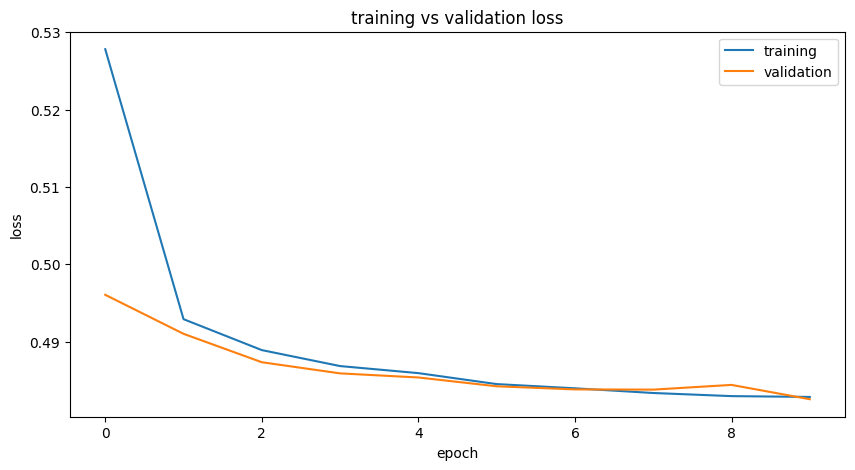

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(histroy.history['loss'])
plt.plot(histroy.history['val_loss'])
plt.ylabel("loss")
plt.xlabel("epoch")
plt.title("training vs validation loss")
plt.legend(["training","validation"])
plt.show()

In [ ]:
#evaluate model
loss = autoencoder.evaluate(validation_generator)
print("Validation loss:",loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - loss: 0.4826
Validation loss: 0.48258090019226074


In [ ]:
#reconstruct images
images,_ = next(validation_generator)
reconstructed = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step


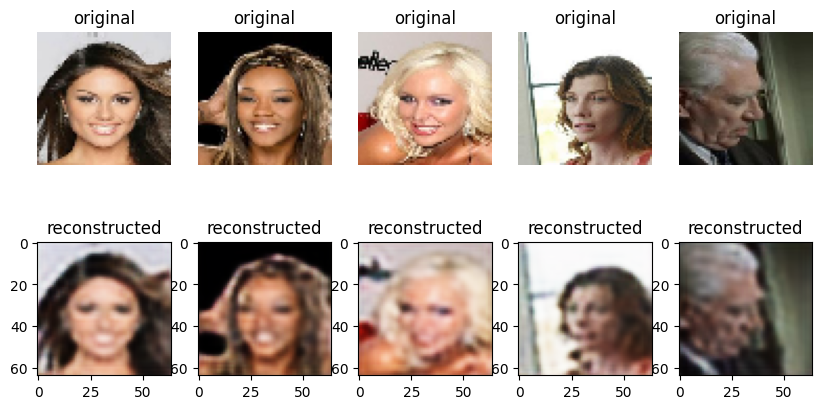

In [ ]:
n=5
plt.figure(figsize=(10,5))
for i in range(n):
  ax=plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("original")
  plt.axis("off")
  plt.subplot(2,n,i+1+n)
  plt.imshow(reconstructed[i])
  plt.title("reconstructed")


REDUCING LOSS ACCURACY [HYPER PARAMETER TUNING]

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [ ]:
import tensorflow as tf

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy'
)

In [ ]:
history = autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 70s 527ms/step - loss: 0.4820 - val_loss: 0.4822
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 66s 528ms/step - loss: 0.4818 - val_loss: 0.4820
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 515ms/step - loss: 0.4817 - val_loss: 0.4819
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 83s 520ms/step - loss: 0.4816 - val_loss: 0.4818
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 521ms/step - loss: 0.4815 - val_loss: 0.4817
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 521ms/step - loss: 0.4814 - val_loss: 0.4816
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 64s 512ms/step - loss: 0.4813 - val_loss: 0.4815
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 522ms/step - loss: 0.4813 - val_loss: 0.4815
Epoch 9/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 523ms/step - loss: 0.4812 - val_loss: 0.4814
Epoch 10/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 520ms/step - loss: 0.4811 - val_loss: 0.4813
Epoch 11/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 65s 519ms/step - loss: 0.4810 - val_loss: 0.4814
Epoch 12/30
125/125

In [27]:
loss = autoencoder.evaluate(validation_generator)
print("Validation loss:", loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - loss: 0.4790
Validation loss: 0.4789751172065735
